# 01 - Modelos Baseline para Forecasting

### Objetivo
Establecer modelos de referencia (baselines) simples contra los cuales comparar modelos más sofisticados. Un buen modelo de forecasting debe superar estos baselines.

### Contexto de negocio (Tarea 3 - Paul, Director Financiero)

> *"DSMarket siempre ha dependido de enfoques rudimentarios para predecir las ventas de productos. La razón principal detrás de tu incorporación temprana es el desarrollo de un nuevo enfoque para la predicción. Tenemos un número importante de casos de uso que dependen de la precisión de esas predicciones."*
>
> *"Hasta ahora, siempre hemos ido prediciendo las ventas a nivel de tienda-producto, y para obtener ventas agregadas por departamento/tienda/ciudad sumamos las predicciones independientes. ¿Seguiría siendo un enfoque válido? Puedes empezar con predicciones de 28 días (4 semanas)."*

### Horizonte de predicción
- **4 semanas** (28 días)
- **Nivel:** tienda-producto (serie_id)
- **Granularidad:** semanal

### Métricas de evaluación
- **RMSE** (Root Mean Squared Error): Penaliza errores grandes
- **MAE** (Mean Absolute Error): Error promedio absoluto
- **MAPE** (Mean Absolute Percentage Error): Error porcentual (interpretable)
- **WRMSSE** (Weighted RMSE Scaled): Métrica usada en competición M5

### Qué conseguiremos
- Benchmark de 4 modelos baseline
- Métricas por segmento (categoría, cluster, tienda)
- Referencia para evaluar modelos ARIMA y ML

## 1. Importación de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 2. Carga de datos

In [4]:
# Cargar dataset con features
df = pd.read_csv('/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/sales_weekly_features.csv')

print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Series únicas: {df['serie_id'].nunique():,}")
print(f"Semanas: {df['yearweek'].nunique()}")
print(f"Rango yearweek: {df['yearweek'].min()} a {df['yearweek'].max()}")

Dataset cargado: 8,384,750 filas x 40 columnas
Series únicas: 30,490
Semanas: 275
Rango yearweek: 201104.0 a 201653.0


In [5]:
# Cargar clusters de productos para análisis por segmento
products_clusters = pd.read_csv('/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/data_dsmarket/processed/products_clustered.csv')

# Ver columnas disponibles
print("Columnas en products_clustered:")
print(products_clusters.columns.tolist())

# Si no existe cluster_name, crearlo
if 'cluster_name' not in products_clusters.columns:
    cluster_names = {
        0: 'Everyday Essentials',
        1: 'Sporadic Sellers',
        2: 'Seasonal Spikes',
        3: 'Star Products',
        4: 'Premium Niche'
    }
    products_clusters['cluster_name'] = products_clusters['cluster'].map(cluster_names)
    print("\nColumna cluster_name creada")

# Unir cluster al dataset principal
df = df.merge(products_clusters[['item', 'cluster', 'cluster_name']], on='item', how='left')

print(f"\nClusters añadidos:")
print(df['cluster_name'].value_counts())

Columnas en products_clustered:
['item', 'category', 'department', 'cluster', 'total_sales', 'mean_sales', 'cv_sales', 'pct_weeks_with_sales', 'mean_price']

Columna cluster_name creada

Clusters añadidos:
cluster_name
Everyday Essentials    4402750
Sporadic Sellers       2607000
Premium Niche           792000
Seasonal Spikes         327250
Star Products           255750
Name: count, dtype: int64


## 3. División Train/Test

Separamos las **últimas 4 semanas** como conjunto de test (horizonte de predicción solicitado por Paul).

In [6]:
# Ordenar por serie y tiempo
df = df.sort_values(['serie_id', 'yearweek']).reset_index(drop=True)

# Identificar las últimas 4 semanas
semanas_unicas = sorted(df['yearweek'].unique())
n_semanas_test = 4

semanas_test = semanas_unicas[-n_semanas_test:]
semanas_train = semanas_unicas[:-n_semanas_test]

print(f"Total semanas: {len(semanas_unicas)}")
print(f"Semanas train: {len(semanas_train)} ({semanas_train[0]} a {semanas_train[-1]})")
print(f"Semanas test: {len(semanas_test)} ({semanas_test[0]} a {semanas_test[-1]})")

# Dividir datasets
train = df[df['yearweek'].isin(semanas_train)].copy()
test = df[df['yearweek'].isin(semanas_test)].copy()

print(f"\nTrain: {len(train):,} filas")
print(f"Test: {len(test):,} filas")

Total semanas: 275
Semanas train: 271 (201104.0 a 201613.0)
Semanas test: 4 (201614.0 a 201653.0)

Train: 8,262,790 filas
Test: 121,960 filas


## 4. Definición de métricas de evaluación

In [7]:
def calculate_rmse(y_true, y_pred):
    """Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(y_true, y_pred))

def calculate_mae(y_true, y_pred):
    """Mean Absolute Error"""
    return mean_absolute_error(y_true, y_pred)

def calculate_mape(y_true, y_pred):
    """Mean Absolute Percentage Error (evita división por cero)"""
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def calculate_smape(y_true, y_pred):
    """Symmetric MAPE (más robusto con ceros)"""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100

def evaluate_predictions(y_true, y_pred, model_name):
    """Calcula todas las métricas para un modelo"""
    return {
        'Modelo': model_name,
        'RMSE': calculate_rmse(y_true, y_pred),
        'MAE': calculate_mae(y_true, y_pred),
        'MAPE': calculate_mape(y_true, y_pred),
        'sMAPE': calculate_smape(y_true, y_pred)
    }

print("Funciones de métricas definidas:")
print("- RMSE: Penaliza errores grandes")
print("- MAE: Error absoluto promedio")
print("- MAPE: Error porcentual (ignora ceros)")
print("- sMAPE: MAPE simétrico (más robusto)")

Funciones de métricas definidas:
- RMSE: Penaliza errores grandes
- MAE: Error absoluto promedio
- MAPE: Error porcentual (ignora ceros)
- sMAPE: MAPE simétrico (más robusto)


## 5. Modelo Naive (Última Semana)

**Predicción = Ventas de la semana anterior**

El modelo más simple: asume que la próxima semana será igual a la última observada.

In [8]:
# Para cada serie, obtener la última semana de train
ultima_semana_train = semanas_train[-1]

# Obtener ventas de la última semana de train por serie
naive_pred = train[train['yearweek'] == ultima_semana_train][['serie_id', 'sales']].copy()
naive_pred.rename(columns={'sales': 'pred_naive'}, inplace=True)

# Unir predicciones al test
test = test.merge(naive_pred, on='serie_id', how='left')

# Rellenar NaN con 0 (series sin datos en última semana)
test['pred_naive'] = test['pred_naive'].fillna(0)

print(f"Predicciones Naive generadas: {test['pred_naive'].notna().sum():,}")
print(f"\nDistribución de predicciones Naive:")
print(test['pred_naive'].describe())

Predicciones Naive generadas: 121,960

Distribución de predicciones Naive:
count   121960.00
mean         9.56
std         21.07
min          0.00
25%          1.00
50%          4.00
75%         10.00
max        727.00
Name: pred_naive, dtype: float64


In [9]:
# Evaluar modelo Naive
results = []
results.append(evaluate_predictions(test['sales'].values, test['pred_naive'].values, 'Naive (última semana)'))

print("Métricas Modelo Naive:")
print(pd.DataFrame([results[-1]]).to_string(index=False))

Métricas Modelo Naive:
               Modelo  RMSE  MAE  MAPE  sMAPE
Naive (última semana) 11.48 4.71 92.16  86.47


## 6. Modelo Media Móvil (4 semanas)

**Predicción = Media de las últimas 4 semanas**

Suaviza fluctuaciones semanales usando el promedio reciente.

In [10]:
# Calcular media de las últimas 4 semanas de train por serie
ultimas_4_semanas = semanas_train[-4:]

media_movil = train[train['yearweek'].isin(ultimas_4_semanas)].groupby('serie_id')['sales'].mean().reset_index()
media_movil.rename(columns={'sales': 'pred_ma4'}, inplace=True)

# Unir al test
test = test.merge(media_movil, on='serie_id', how='left')
test['pred_ma4'] = test['pred_ma4'].fillna(0)

print(f"Predicciones Media Móvil 4 generadas")
print(f"\nDistribución de predicciones MA4:")
print(test['pred_ma4'].describe())

Predicciones Media Móvil 4 generadas

Distribución de predicciones MA4:
count   121960.00
mean         9.55
std         20.99
min          0.00
25%          1.50
50%          4.00
75%          9.50
max        781.50
Name: pred_ma4, dtype: float64


In [11]:
# Evaluar modelo Media Móvil
results.append(evaluate_predictions(test['sales'].values, test['pred_ma4'].values, 'Media Móvil (4 sem)'))

print("Métricas Modelo Media Móvil 4:")
print(pd.DataFrame([results[-1]]).to_string(index=False))

Métricas Modelo Media Móvil 4:
             Modelo  RMSE  MAE  MAPE  sMAPE
Media Móvil (4 sem) 11.24 4.31 80.68  81.33


## 7. Modelo Media Histórica

**Predicción = Media de toda la historia de la serie**

Modelo conservador que usa todo el historial disponible.

In [12]:
# Calcular media histórica de cada serie (todo el train)
media_historica = train.groupby('serie_id')['sales'].mean().reset_index()
media_historica.rename(columns={'sales': 'pred_hist'}, inplace=True)

# Unir al test
test = test.merge(media_historica, on='serie_id', how='left')
test['pred_hist'] = test['pred_hist'].fillna(0)

print(f"Predicciones Media Histórica generadas")
print(f"\nDistribución de predicciones Histórica:")
print(test['pred_hist'].describe())

Predicciones Media Histórica generadas

Distribución de predicciones Histórica:
count   121960.00
mean         7.83
std         19.03
min          0.02
25%          1.28
50%          3.07
75%          7.37
max        915.64
Name: pred_hist, dtype: float64


In [13]:
# Evaluar modelo Media Histórica
results.append(evaluate_predictions(test['sales'].values, test['pred_hist'].values, 'Media Histórica'))

print("Métricas Modelo Media Histórica:")
print(pd.DataFrame([results[-1]]).to_string(index=False))

Métricas Modelo Media Histórica:
         Modelo  RMSE  MAE  MAPE  sMAPE
Media Histórica 13.38 5.25 76.79  93.92


## 8. Modelo Seasonal Naive (hace 52 semanas)

**Predicción = Ventas de hace 52 semanas (mismo periodo del año anterior)**

Captura estacionalidad anual.

In [14]:
# Seasonal Naive OPTIMIZADO (vectorizado)
print("Calculando predicciones Seasonal Naive (optimizado)...")

# Crear columna de yearweek de hace 52 semanas
test['year'] = (test['yearweek'] // 100).astype(int)
test['week'] = (test['yearweek'] % 100).astype(int)
test['yearweek_prev'] = (test['year'] - 1) * 100 + test['week']

# Crear lookup de ventas históricas por serie_id y yearweek
train_lookup = train.set_index(['serie_id', 'yearweek'])['sales'].to_dict()

# Buscar ventas de hace 52 semanas usando el lookup
test['pred_seasonal'] = test.apply(
    lambda row: train_lookup.get((row['serie_id'], row['yearweek_prev']), np.nan),
    axis=1
)

# Rellenar NaN con media histórica de la serie
media_por_serie = train.groupby('serie_id')['sales'].mean().to_dict()
test['pred_seasonal'] = test.apply(
    lambda row: row['pred_seasonal'] if not np.isnan(row['pred_seasonal']) 
                else media_por_serie.get(row['serie_id'], 0),
    axis=1
)

# Limpiar columnas auxiliares
test.drop(columns=['year', 'week', 'yearweek_prev'], inplace=True, errors='ignore')

print(f"✓ Predicciones Seasonal Naive generadas")
print(f"\nDistribución de predicciones Seasonal:")
print(test['pred_seasonal'].describe())

Calculando predicciones Seasonal Naive (optimizado)...
✓ Predicciones Seasonal Naive generadas

Distribución de predicciones Seasonal:
count   121960.00
mean         7.60
std         18.90
min          0.00
25%          0.00
50%          3.00
75%          8.00
max        868.00
Name: pred_seasonal, dtype: float64


In [15]:
# Evaluar modelo Seasonal Naive
results.append(evaluate_predictions(test['sales'].values, test['pred_seasonal'].values, 'Seasonal Naive (52 sem)'))

print("Métricas Modelo Seasonal Naive:")
print(pd.DataFrame([results[-1]]).to_string(index=False))

Métricas Modelo Seasonal Naive:
                 Modelo  RMSE  MAE  MAPE  sMAPE
Seasonal Naive (52 sem) 13.42 5.36 85.70  98.99


## 9. Comparación de Modelos Baseline

In [16]:
# Tabla resumen de todos los baselines
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')

print("=" * 70)
print("COMPARACIÓN DE MODELOS BASELINE")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

# Mejor modelo
mejor = results_df.iloc[0]['Modelo']
print(f"\n🏆 Mejor baseline (menor RMSE): {mejor}")

COMPARACIÓN DE MODELOS BASELINE
                 Modelo  RMSE  MAE  MAPE  sMAPE
    Media Móvil (4 sem) 11.24 4.31 80.68  81.33
  Naive (última semana) 11.48 4.71 92.16  86.47
        Media Histórica 13.38 5.25 76.79  93.92
Seasonal Naive (52 sem) 13.42 5.36 85.70  98.99

🏆 Mejor baseline (menor RMSE): Media Móvil (4 sem)


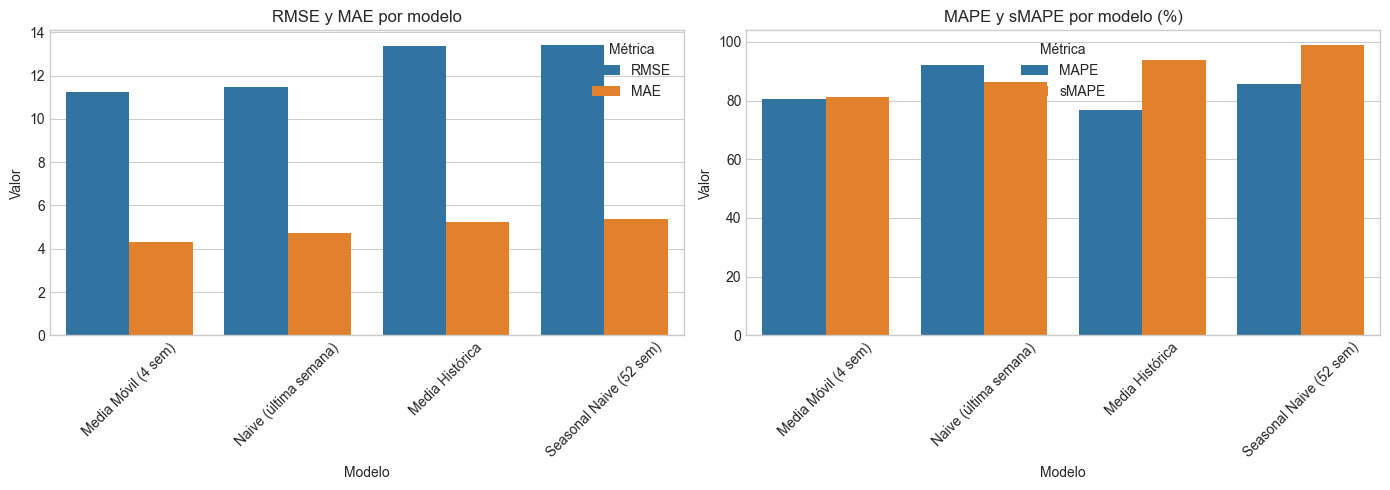

In [17]:
# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE y MAE
metrics_plot = results_df.melt(id_vars='Modelo', value_vars=['RMSE', 'MAE'], 
                                var_name='Métrica', value_name='Valor')
sns.barplot(data=metrics_plot, x='Modelo', y='Valor', hue='Métrica', ax=axes[0])
axes[0].set_title('RMSE y MAE por modelo')
axes[0].tick_params(axis='x', rotation=45)

# MAPE y sMAPE
metrics_plot2 = results_df.melt(id_vars='Modelo', value_vars=['MAPE', 'sMAPE'], 
                                 var_name='Métrica', value_name='Valor')
sns.barplot(data=metrics_plot2, x='Modelo', y='Valor', hue='Métrica', ax=axes[1])
axes[1].set_title('MAPE y sMAPE por modelo (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. Análisis por segmento

¿Qué baseline funciona mejor para cada tipo de producto?

In [18]:
# Métricas por cluster de producto
def metrics_by_segment(df, segment_col, pred_col):
    """Calcula métricas agrupadas por segmento"""
    results = []
    for segment in df[segment_col].unique():
        mask = df[segment_col] == segment
        y_true = df.loc[mask, 'sales'].values
        y_pred = df.loc[mask, pred_col].values
        
        results.append({
            segment_col: segment,
            'RMSE': calculate_rmse(y_true, y_pred),
            'MAE': calculate_mae(y_true, y_pred),
            'n_obs': len(y_true)
        })
    return pd.DataFrame(results)

# Métricas por cluster para el mejor baseline
mejor_pred_col = 'pred_ma4'  # Ajustar según resultados

metrics_cluster = metrics_by_segment(test, 'cluster_name', mejor_pred_col)
metrics_cluster = metrics_cluster.sort_values('RMSE')

print(f"Métricas de '{mejor_pred_col}' por Cluster de Producto:")
print(metrics_cluster.to_string(index=False))

Métricas de 'pred_ma4' por Cluster de Producto:
       cluster_name  RMSE   MAE  n_obs
      Premium Niche  4.15  2.10  11520
   Sporadic Sellers  5.81  2.74  37920
    Seasonal Spikes  7.19  3.43   4760
Everyday Essentials  8.12  4.34  64040
      Star Products 50.45 27.64   3720


In [19]:
# Métricas por categoría
metrics_category = metrics_by_segment(test, 'category', mejor_pred_col)
metrics_category = metrics_category.sort_values('RMSE')

print(f"\nMétricas de '{mejor_pred_col}' por Categoría:")
print(metrics_category.to_string(index=False))


Métricas de 'pred_ma4' por Categoría:
     category  RMSE  MAE  n_obs
   ACCESORIES  5.10 2.51  22600
HOME_&_GARDEN  6.57 3.07  41880
  SUPERMARKET 15.05 5.91  57480


In [20]:
# Métricas por tienda
metrics_store = metrics_by_segment(test, 'store', mejor_pred_col)
metrics_store = metrics_store.sort_values('RMSE')

print(f"\nMétricas de '{mejor_pred_col}' por Tienda:")
print(metrics_store.to_string(index=False))


Métricas de 'pred_ma4' por Tienda:
            store  RMSE  MAE  n_obs
         Brooklyn  5.81 2.93  12196
  Midtown_Village  7.66 3.70  12196
           Harlem  9.05 4.25  12196
        South_End  9.13 3.59  12196
Greenwich_Village 10.25 4.53  12196
         Back_Bay 10.45 4.09  12196
          Roxbury 11.26 4.15  12196
    Queen_Village 11.41 4.17  12196
          Tribeca 16.34 6.10  12196
         Yorktown 16.39 5.57  12196


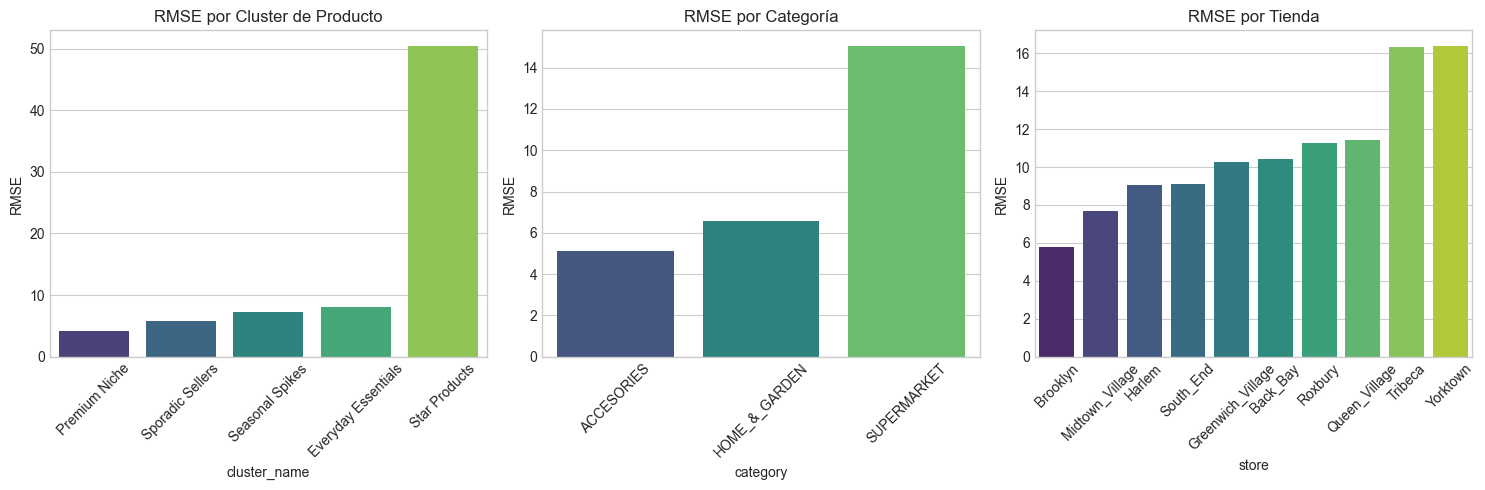

In [21]:
# Visualizar RMSE por cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Por cluster
sns.barplot(data=metrics_cluster, x='cluster_name', y='RMSE', ax=axes[0], palette='viridis')
axes[0].set_title('RMSE por Cluster de Producto')
axes[0].tick_params(axis='x', rotation=45)

# Por categoría
sns.barplot(data=metrics_category, x='category', y='RMSE', ax=axes[1], palette='viridis')
axes[1].set_title('RMSE por Categoría')
axes[1].tick_params(axis='x', rotation=45)

# Por tienda
sns.barplot(data=metrics_store, x='store', y='RMSE', ax=axes[2], palette='viridis')
axes[2].set_title('RMSE por Tienda')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 11. Guardar predicciones baseline

In [23]:
# Guardar predicciones de test con todos los baselines
output_cols = ['yearweek', 'serie_id', 'item', 'store', 'category', 'cluster_name',
               'sales', 'pred_naive', 'pred_ma4', 'pred_hist', 'pred_seasonal']

output_path = '/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/forecasting/baseline_predictions.csv'
test[output_cols].to_csv(output_path, index=False)

print(f"✓ Predicciones baseline guardadas en: {output_path}")
print(f"  Filas: {len(test):,}")
print(f"  Columnas: {output_cols}")

✓ Predicciones baseline guardadas en: /Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/forecasting/baseline_predictions.csv
  Filas: 121,960
  Columnas: ['yearweek', 'serie_id', 'item', 'store', 'category', 'cluster_name', 'sales', 'pred_naive', 'pred_ma4', 'pred_hist', 'pred_seasonal']


In [24]:
# Guardar resumen de métricas
metrics_path = '/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/forecasting/baseline_metrics.csv'
results_df.to_csv(metrics_path, index=False)

print(f"✓ Métricas baseline guardadas en: {metrics_path}")

✓ Métricas baseline guardadas en: /Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/forecasting/baseline_metrics.csv
